# Vision Transformers in Keras

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 3

**Objective:** Combine a convolutional neural network (CNN) with a Vision
Transformer (ViT) for advanced image classification: extract intermediate
CNN feature maps, reshape them as tokens, add positional embeddings, and
stack Transformer encoder blocks on top, so the model benefits from both
local (convolutional) detail extraction and global (self-attention)
context awareness.

**Prerequisite:** run the Keras CNN training lab first, so that
`keras_cnn_classifier.keras` exists.


## 1. Import libraries and packages

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("images_dataSAT")
MODELS_DIR = Path(".")
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

assert (MODELS_DIR / "keras_cnn_classifier.keras").exists(), \
    "Pretrained Keras CNN not found -- run the Keras training lab first."


I0000 00:00:1782894103.654534    3237 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782894103.696307    3237 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782894104.987412    3237 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Load data

In [2]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR, labels="inferred", label_mode="binary",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.2, subset="training", seed=SEED,
)
val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR, labels="inferred", label_mode="binary",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    validation_split=0.2, subset="validation", seed=SEED,
)

normalization = layers.Rescaling(1.0 / 255)
train_ds_ready = train_ds.map(lambda x, y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds_ready = val_ds.map(lambda x, y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)

print("Data ready.")


Found 6000 files belonging to 2 classes.


Using 4800 files for training.


Found 6000 files belonging to 2 classes.


Using 1200 files for validation.


Data ready.


## 3. Load the pretrained CNN and extract a feature-map sub-model

We reuse the CNN trained in an earlier lab as a **frozen feature
extractor**: we cut it off after the last convolutional block (before
`Flatten`/`Dense`), giving us an `(8, 8, 128)` feature map per image.


In [3]:
pretrained_cnn = keras.models.load_model(MODELS_DIR / "keras_cnn_classifier.keras")
pretrained_cnn.summary()


Model: "satellite_cnn_keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,428,037 (13.08 MB)

 Trainable params: 1,142,529 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2,285,060 (8.72 MB)

In [4]:
# Identify the last MaxPooling2D layer (end of the convolutional feature extractor)
last_pool_idx = max(i for i, l in enumerate(pretrained_cnn.layers) if isinstance(l, layers.MaxPooling2D))
print("Using feature map up to layer:", pretrained_cnn.layers[last_pool_idx].name)

# Rebuild a functional feature-extractor graph by replaying the loaded (trained) layers.
# (A reloaded Sequential model doesn't retain a usable `.input` handle in Keras 3, so we
# reconstruct the functional graph explicitly, reusing the same trained layer objects/weights.)
fe_inputs = keras.Input(shape=(64, 64, 3))
x = fe_inputs
for layer in pretrained_cnn.layers[: last_pool_idx + 1]:
    x = layer(x)

feature_extractor = keras.Model(inputs=fe_inputs, outputs=x, name="cnn_feature_extractor")
feature_extractor.trainable = False  # freeze -- we only train the new ViT head

print("Feature extractor output shape:", feature_extractor.output.shape)

sample_batch, _ = next(iter(train_ds_ready))
sample_features = feature_extractor(sample_batch)
print("Feature map shape for a batch:", sample_features.shape)  # (batch, 8, 8, 128)


Using feature map up to layer: max_pooling2d_2
Feature extractor output shape: (None, 8, 8, 128)
Feature map shape for a batch: (32, 8, 8, 128)


W0000 00:00:1782894106.591819    3237 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 4. CNN feature maps -> tokens + positional embeddings

The `(8, 8, 128)` feature map is reshaped into a sequence of `8*8 = 64`
tokens, each of dimension `128`. A learnable positional embedding is added
to each token so the Transformer can distinguish token positions (since
self-attention itself is permutation-invariant).


In [5]:
class PatchTokenizer(layers.Layer):
    """Reshape a (H, W, C) CNN feature map into a (num_tokens, C) token sequence."""

    def call(self, feature_map):
        shape = tf.shape(feature_map)
        batch, h, w, c = shape[0], shape[1], shape[2], shape[3]
        tokens = tf.reshape(feature_map, (batch, h * w, c))
        return tokens


class PositionalEmbedding(layers.Layer):
    """Learnable positional embedding added to each token."""

    def __init__(self, num_tokens, dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_embedding = self.add_weight(
            name="pos_embedding", shape=(1, num_tokens, dim), initializer="random_normal", trainable=True,
        )

    def call(self, tokens):
        return tokens + self.pos_embedding


NUM_TOKENS = 8 * 8   # from the 8x8 feature map
TOKEN_DIM = 128       # channel depth of the feature map

tokenizer = PatchTokenizer()
pos_embed = PositionalEmbedding(NUM_TOKENS, TOKEN_DIM)

sample_tokens = pos_embed(tokenizer(sample_features))
print("Token sequence shape:", sample_tokens.shape)  # (batch, 64, 128)


Token sequence shape: (32, 64, 128)


## 5. Transformer encoder blocks

Each block: multi-head self-attention (with a residual connection and
`LayerNormalization`), followed by an MLP feed-forward block (also with a
residual connection and `LayerNormalization`) — the standard Transformer
encoder design used in ViT.


In [6]:
def transformer_encoder_block(x, num_heads=4, key_dim=32, mlp_dim=256, dropout=0.1, name="block"):
    # --- Multi-head self-attention sub-block ---
    attn_input = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout, name=f"{name}_mha"
    )(attn_input, attn_input)
    x = layers.Add(name=f"{name}_add1")([x, attn_output])

    # --- MLP feed-forward sub-block ---
    mlp_input = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x)
    mlp_output = layers.Dense(mlp_dim, activation="gelu", name=f"{name}_dense1")(mlp_input)
    mlp_output = layers.Dropout(dropout, name=f"{name}_drop")(mlp_output)
    mlp_output = layers.Dense(x.shape[-1], name=f"{name}_dense2")(mlp_output)
    x = layers.Add(name=f"{name}_add2")([x, mlp_output])

    return x


## 6. Assemble the full CNN-ViT hybrid model

In [7]:
def build_cnn_vit_hybrid(feature_extractor, num_tokens, token_dim,
                          num_transformer_blocks=2, num_heads=4):
    inputs = keras.Input(shape=(64, 64, 3))

    feature_map = feature_extractor(inputs, training=False)  # (H, W, C), frozen CNN
    x = PatchTokenizer(name="tokenizer")(feature_map)
    x = PositionalEmbedding(num_tokens, token_dim, name="pos_embed")(x)

    for i in range(num_transformer_blocks):
        x = transformer_encoder_block(x, num_heads=num_heads, key_dim=token_dim // num_heads,
                                       mlp_dim=token_dim * 2, name=f"transformer_block_{i}")

    x = layers.LayerNormalization(epsilon=1e-6, name="final_ln")(x)
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="classifier_head")(x)

    return keras.Model(inputs, outputs, name="cnn_vit_hybrid_keras")


cnn_vit_model = build_cnn_vit_hybrid(feature_extractor, NUM_TOKENS, TOKEN_DIM)
cnn_vit_model.summary()


Model: "cnn_vit_hybrid_keras"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_feature_extrac… │ (None, 8, 8, 128) │     94,144 │ input_layer_1[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tokenizer           │ (None, 64, 128)   │          0 │ cnn_feature_extr… │
│ (PatchTokenizer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_embed           │ (None, 64, 128)   │      8,192 │ tokenizer[0][0]   │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │        256 │ pos_embed[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │     66,048 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │          0 │ pos_embed[0][0],  │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 256)   │     33,024 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 256)   │          0 │ transformer_bloc… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │     32,896 │ transformer_bloc… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │          0 │ transformer_bloc… │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │     66,048 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │          0 │ transformer_bloc… │
│ (Add)               │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 128)   │        256 │ transformer_bloc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 64, 256)   │     33,024 │ transformer_bloc

 Total params: 367,681 (1.40 MB)

 Trainable params: 273,537 (1.04 MB)

 Non-trainable params: 94,144 (367.75 KB)

## 7. Compile and train

In [8]:
cnn_vit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

EPOCHS = 5
history = cnn_vit_model.fit(
    train_ds_ready,
    validation_data=val_ds_ready,
    epochs=EPOCHS,
    verbose=2,
)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


150/150 - 26s - 173ms/step - accuracy: 0.9929 - loss: 0.0217 - val_accuracy: 0.9950 - val_loss: 0.0182


Epoch 2/5


150/150 - 20s - 133ms/step - accuracy: 0.9967 - loss: 0.0088 - val_accuracy: 0.9958 - val_loss: 0.0191


...

150/150 - 20s - 135ms/step - accuracy: 0.9983 - loss: 0.0074 - val_accuracy: 0.9967 - val_loss: 0.0093


Epoch 4/5


150/150 - 20s - 137ms/step - accuracy: 0.9996 - loss: 0.0026 - val_accuracy: 0.9950 - val_loss: 0.0124


Epoch 5/5


150/150 - 20s - 136ms/step - accuracy: 0.9998 - loss: 0.0017 - val_accuracy: 0.9958 - val_loss: 0.0138


## 8. Performance visualization

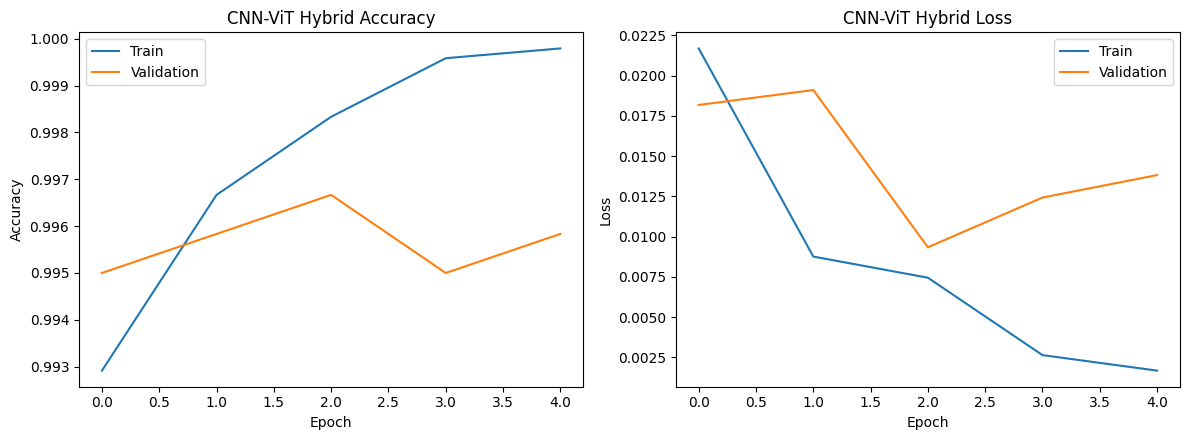

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("CNN-ViT Hybrid Accuracy")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("CNN-ViT Hybrid Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Evaluation

In [10]:
y_true, y_pred_proba = [], []
for x_batch, y_batch in val_ds_ready:
    preds = cnn_vit_model.predict(x_batch, verbose=0).ravel()
    y_pred_proba.extend(preds)
    y_true.extend(y_batch.numpy().ravel())

y_true = np.array(y_true)
y_pred = (np.array(y_pred_proba) >= 0.5).astype(int)

print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred):.4f}")


Accuracy : 0.9958
Precision: 0.9968
Recall   : 0.9952
F1-score : 0.9960


## 10. Save the hybrid model (needed for the final integration lab)

In [11]:
MODELS_DIR.mkdir(exist_ok=True)
cnn_vit_model.save(MODELS_DIR / "keras_cnn_vit_hybrid.keras")
print(f"Saved model to {MODELS_DIR / 'keras_cnn_vit_hybrid.keras'}")


Saved model to keras_cnn_vit_hybrid.keras


## Summary

We built a CNN-ViT hybrid image classification model in Keras: starting
from a pretrained CNN, we extracted intermediate feature maps, reshaped
them as tokens, added positional embeddings, and stacked Transformer
encoder blocks on top. This lets the model benefit from both local detail
extraction (the frozen convolutional base) and global context awareness
(self-attention across the whole feature map).
